# Методы и средства защиты информации
---
## Практика 2 - Нейросеть
---
## Выполнили:
- Агафонов Р.В.
- Вахитов Т.Р.
- Лепоринский Г.А.
- Шарыгин М.С.
- Юлдашева Г.А.

## Нейросеть

### Импорт библиотек

In [11]:
import os
import numpy             as np
import matplotlib.pyplot as plt

from tensorflow.keras                     import models, layers
from tensorflow.keras.optimizers          import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator


### Загрузка данных

In [2]:
train_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'Train',
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

validation_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'Validation',
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'Test',
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 140002 images belonging to 2 classes.
Found 39428 images belonging to 2 classes.
Found 10905 images belonging to 2 classes.


### Архитектура модели

In [6]:
model = models.Sequential([
    # Входной слой
    layers.Input(shape=(256, 256, 3)),

    # Сверточные блоки
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    # Преобразование в вектор
    layers.Flatten(),

    # Полносвязные слои
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    # Выходной слой
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,076,993 (129.99 MB)

 Trainable params: 34,075,969 (129.99 MB)

 Non-trainable params: 1,024 (4.00 KB)

### Обучение модели

In [8]:
log = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    steps_per_epoch=300,
    validation_steps=50
)


Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 377s 1s/step - accuracy: 0.8047 - loss: 0.4162 - precision: 0.7935 - recall: 0.8254 - val_accuracy: 0.7425 - val_loss: 0.5076 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 375s 1s/step - accuracy: 0.8474 - loss: 0.3492 - precision: 0.8394 - recall: 0.8611 - val_accuracy: 0.5494 - val_loss: 0.9582 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 377s 1s/step - accuracy: 0.8669 - loss: 0.3048 - precision: 0.8650 - recall: 0.8718 - val_accuracy: 0.9944 - val_loss: 0.0337 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 390s 1s/step - accuracy: 0.8909 - loss: 0.2578 - precision: 0.8844 - recall: 0.8965 - val_accuracy: 0.8913 - val_loss: 0.2623 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.9071 - loss: 0.2277 - precision: 0.9090 - recall: 0.9048 

### Тестирование модели

In [9]:
model.evaluate(test_generator)


341/341 ━━━━━━━━━━━━━━━━━━━━ 85s 248ms/step - accuracy: 0.8333 - loss: 0.3817 - precision: 0.8593 - recall: 0.7942


[0.3816574215888977,
 0.8332874774932861,
 0.8592844009399414,
 0.7941991686820984]

### Анализ результатов

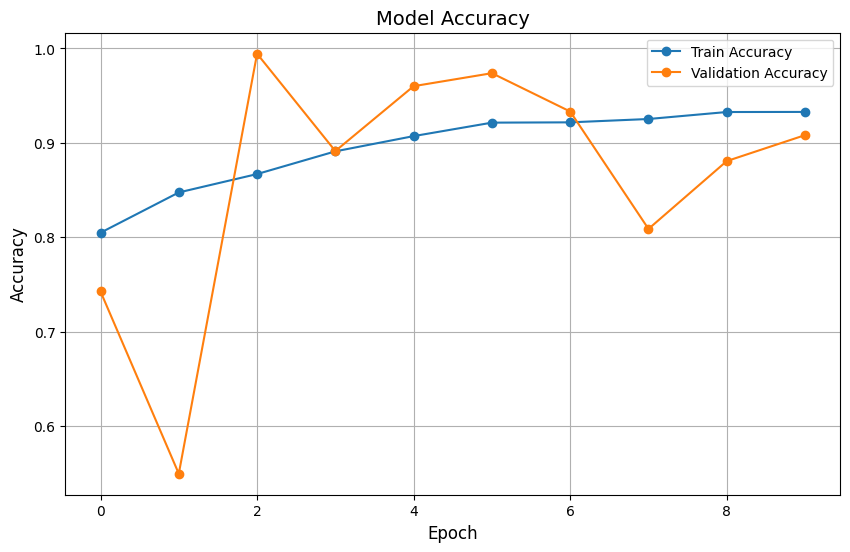

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(log.history['accuracy'],     label='Train Accuracy',      marker='o')
plt.plot(log.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch',    fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()
